<a href="https://colab.research.google.com/github/esraaabdullahh/Data-Mining-Project/blob/main/Fake_Account_Detection_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProfileLens: Fake Account Detection
**by: Esraa Abdullah — Data Mining project**

This project compares three classifiers using eight numeric Instagram profile features. The notebook downloads the dataset, trains the models, evaluates them and provides a prediction form.

To run: select **Runtime → Run all** and wait for training to finish. Use Python 3 and CPU. Internet access is needed for the dataset download. Save the notebook and download the results before ending the session.


## 1. Setup and data download
The first cell checks the required libraries. The next cell downloads the two source JSON files from a fixed repository revision and records their hashes. The model is trained in the current runtime.


In [1]:
import sys, subprocess, importlib.metadata as metadata
from pathlib import Path
from packaging.version import Version

requirements = {
    "numpy": "1.26",
    "pandas": "2.0",
    "scikit-learn": "1.5",
    "matplotlib": "3.8",
    "joblib": "1.3",
    "Pillow": "10.0",
    "ipywidgets": "8.0",
}
needed = []
for package, minimum in requirements.items():
    try:
        if Version(metadata.version(package)) < Version(minimum):
            needed.append(f"{package}>={minimum}")
    except metadata.PackageNotFoundError:
        needed.append(f"{package}>={minimum}")
if needed:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--only-binary=:all:",
            *needed,
        ],
        check=True,
    )
print("Environment ready. Python:", sys.version.split()[0])


Environment ready. Python: 3.13.15


In [2]:
# Download the original dataset from its published source.
from pathlib import Path
from urllib.request import urlopen
import os, sys, json, io, hashlib

ROOT = (
    Path("/content") if Path("/content").is_dir() else Path.cwd()
) / "profilelens_colab"
for folder in ["data/raw", "src", "results"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)

COMMIT = "cf669b27283aa3bc0fa6b8d185d4e611e9061ac1"
BASE_URL = f"https://raw.githubusercontent.com/fcakyon/instafake-dataset/{COMMIT}/data/fake-v1.0/"
FILES = ["fakeAccountData.json", "realAccountData.json"]
source_files = []

for filename in FILES:
    with urlopen(BASE_URL + filename, timeout=60) as response:
        content = response.read()
    json.loads(content)  # Check that the downloaded file is valid JSON.
    (ROOT / "data/raw" / filename).write_bytes(content)
    source_files.append(
        {
            "filename": filename,
            "url": BASE_URL + filename,
            "sha256": hashlib.sha256(content).hexdigest(),
        }
    )
    print("Downloaded:", filename)

provenance = {
    "repository": "https://github.com/fcakyon/instafake-dataset",
    "commit": COMMIT,
    "license": "CC BY-NC 4.0",
    "files": source_files,
}
(ROOT / "data/provenance.json").write_text(json.dumps(provenance, indent=2))
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Data ready. Continue to the next cell.")


Downloaded: fakeAccountData.json
Downloaded: realAccountData.json
Data ready. Continue to the next cell.


## 2. Problem and dataset
**Research question:** Can eight numeric profile attributes help distinguish accounts labelled fake from those labelled genuine?

**Source:** Fatih Cagatay Akyon and Esat Kalfaoglu, [instafake-dataset](https://github.com/fcakyon/instafake-dataset), `data/fake-v1.0`, commit `cf669b27283aa3bc0fa6b8d185d4e611e9061ac1`. Related [research paper](https://arxiv.org/abs/1910.03090). Source license: **CC BY-NC 4.0**; retain attribution and use noncommercially.

The downloaded JSON contains **1,194 rows: 994 genuine and 200 fake labels**, collected in 2018. The paper reports 1,203 accounts; we report the actual downloaded file count and do not assume a reason for the discrepancy.

| Feature | Meaning |
|---|---|
| followers | Number of followers |
| following | Number of accounts followed |
| bio_length | Number of characters in the biography |
| posts | Number of posts |
| has_profile_pic | Profile picture present: 1 = yes, 0 = no |
| is_private | Private account: 1 = yes, 0 = no |
| username_digits | Number of digits in the username |
| username_length | Total username length |

Target: `is_fake`, with 1 = fake label and 0 = genuine label. No usernames, passwords or live account lookup are needed.


In [3]:
import pandas as pd

raw_frames = []
for name in ["fakeAccountData.json", "realAccountData.json"]:
    raw_frames.append(pd.DataFrame(json.loads((ROOT / "data/raw" / name).read_text())))
raw = pd.concat(raw_frames, ignore_index=True)
print("Raw shape:", raw.shape)
display(raw.head())
display(raw["isFake"].value_counts().rename_axis("Label").to_frame("Rows"))
print("Missing cells:", raw.isna().sum().sum())


Raw shape: (1194, 9)


,userFollowerCount,userFollowingCount,userBiographyLength,userMediaCount,userHasProfilPic,userIsPrivate,usernameDigitCount,usernameLength,isFake
0,25,1937,0,0,1,1,0,10,1
1,324,4122,0,0,1,0,4,15,1
2,15,399,0,0,0,0,3,12,1
3,14,107,0,1,1,0,1,10,1
4,264,4651,0,0,1,0,0,14,1


,Rows
Label,
0,994
1,200


Missing cells: 0


## 3. Preprocessing
The next two cells save the feature-processing and prediction functions as Python modules.

- Check numeric values, binary flags and username lengths.
- Remove exact repeated feature-and-label rows before splitting: 1,194 records become 1,165. Without account IDs, matching measurements might belong to different accounts.
- Check for conflicting labels. No missing values or conflicting labels were found in this dataset.
- Apply `log1p` to followers, following, biography length and posts.
- Add relative following activity, username digit fraction and a no-posts indicator, giving 11 features.
- Keep median imputation inside the pipeline and use standardization for Logistic Regression only. These steps are fitted on training data within each fold.

Valid extreme counts are retained. No oversampling is used.


In [4]:
%%writefile src/features.py
"""Shared schema, validation and transparent feature engineering."""

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

FEATURES = [
    "followers",
    "following",
    "bio_length",
    "posts",
    "has_profile_pic",
    "is_private",
    "username_digits",
    "username_length",
]
SOURCE_NAMES = [
    "userFollowerCount",
    "userFollowingCount",
    "userBiographyLength",
    "userMediaCount",
    "userHasProfilPic",
    "userIsPrivate",
    "usernameDigitCount",
    "usernameLength",
]
LABELS = {
    "followers": "Followers",
    "following": "Following",
    "bio_length": "Biography length",
    "posts": "Posts",
    "has_profile_pic": "Profile picture",
    "is_private": "Private account",
    "username_digits": "Digits in username",
    "username_length": "Username length",
}
COUNT_COLUMNS = ["followers", "following", "bio_length", "posts"]


def validate_frame(frame, allow_missing=True):
    """Reject impossible values. NaN is permitted for training-fold imputation."""
    if set(frame.columns) != set(FEATURES):
        raise ValueError("Expected exactly these columns: " + ", ".join(FEATURES))
    X = frame[FEATURES].apply(pd.to_numeric, errors="raise").copy()
    if np.isinf(X.to_numpy()).any():
        raise ValueError("Infinite values are not valid.")
    if not allow_missing and X.isna().any().any():
        raise ValueError("Complete all eight inputs.")
    if (X < 0).any().any():
        raise ValueError("Counts cannot be negative.")
    values = X.to_numpy()
    valid = values[~np.isnan(values)]
    if np.any(valid != np.floor(valid)):
        raise ValueError("Counts and flags must be whole numbers.")
    for c in ["has_profile_pic", "is_private"]:
        if not X[c].dropna().isin([0, 1]).all():
            raise ValueError(c + " must be 0 or 1.")
    if (X.username_length.dropna() < 1).any():
        raise ValueError("Username length must be at least 1.")
    if (X.username_digits > X.username_length).any():
        raise ValueError("Digit count cannot exceed username length.")
    return X


class ProfileFeatures(BaseEstimator, TransformerMixin):
    """Stateless transformation; median imputation precedes this step in the pipeline."""

    def __init__(self, engineered=True):
        self.engineered = engineered

    def fit(self, X, y=None):
        self.n_features_in_ = np.asarray(X).shape[1]
        return self

    def transform(self, X):
        a = np.asarray(X, dtype=float)
        out = a.copy()
        # Heavy-tailed count scales are compressed without deleting large accounts.
        out[:, :4] = np.log1p(a[:, :4])
        if self.engineered:
            ratio = np.log1p(a[:, 1]) - np.log1p(a[:, 0])
            digits = a[:, 6] / np.maximum(a[:, 7], 1)
            no_posts = (a[:, 3] == 0).astype(float)
            out = np.column_stack([out, ratio, digits, no_posts])
        return out

    def get_feature_names_out(self, input_features=None):
        names = [
            "log_followers",
            "log_following",
            "log_bio_length",
            "log_posts",
            *FEATURES[4:],
        ]
        return np.array(
            names
            + (
                ["log_following_follower_ratio", "username_digit_fraction", "no_posts"]
                if self.engineered
                else []
            ),
            dtype=object,
        )


Writing src/features.py


In [5]:
%%writefile src/predict.py
"""Shared inference used by the desktop GUI and command line."""

from pathlib import Path
import json, argparse
import pandas as pd
import joblib
from features import validate_frame, FEATURES

ROOT = Path(__file__).resolve().parents[1]


def load_artifacts():
    p = ROOT / "results/selected_model.joblib"
    if not p.exists():
        raise FileNotFoundError("Run python src/run_project.py first.")
    return (
        joblib.load(p),
        json.loads((ROOT / "results/selection.json").read_text()),
        json.loads((ROOT / "results/training_ranges.json").read_text()),
    )


def predict_frame(frame, model=None):
    X = validate_frame(frame, allow_missing=False)
    if len(X) == 0:
        raise ValueError("The input CSV has no rows.")
    if model is None:
        model, _, _ = load_artifacts()
    scores = model.predict_proba(X)[:, 1]
    out = X.copy()
    out["fake_model_score"] = scores
    out["predicted_label"] = (scores >= 0.5).astype(int)
    out["prediction"] = out.predicted_label.map(
        {0: "Predicted genuine", 1: "Predicted fake"}
    )
    return out


def main():
    ap = argparse.ArgumentParser(description=__doc__)
    ap.add_argument("csv", type=Path)
    ap.add_argument(
        "--output", type=Path, default=ROOT / "results/batch_predictions.csv"
    )
    a = ap.parse_args()
    out = predict_frame(pd.read_csv(a.csv))
    a.output.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(a.output, index=False)
    print(out[["prediction", "fake_model_score"]].to_string(index=False))
    print("Uncalibrated model scores, not proof of account identity.")
    print("Saved:", a.output)


if __name__ == "__main__":
    main()


Writing src/predict.py


## 4. Models and evaluation
The majority baseline always predicts the most common class. Logistic Regression provides a linear comparison; Decision Tree and Random Forest model nonlinear relationships.

The cleaned data are split into 932 training and 233 test records using a stratified 80/20 split with seed 42. GridSearchCV compares the settings below using five-fold training cross-validation. The learned model with the highest mean fake-class F1 is selected before the test results are calculated.

A fixed score threshold of 0.50 is used throughout. The code reports accuracy, precision, recall, F1, ROC-AUC, average precision and the confusion matrix.


In [6]:
%%writefile src/run_project.py
"""Reproduce the complete fake-account experiment with one command."""

from pathlib import Path
import json, hashlib, platform, time, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance
from features import FEATURES, SOURCE_NAMES, ProfileFeatures, validate_frame

ROOT = Path(__file__).resolve().parents[1]
SEED = 42


def threshold_f1(y, score):
    return f1_score(y, np.asarray(score) >= 0.5, zero_division=0)


FAKE_F1 = make_scorer(threshold_f1, response_method="predict_proba")


def write_json(p, o):
    p.write_text(
        json.dumps(
            o, indent=2, default=lambda v: v.item() if hasattr(v, "item") else str(v)
        ),
        encoding="utf-8",
    )


def make_pipeline(model, scaled=False, engineered=True):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("features", ProfileFeatures(engineered)),
            ("scaler", StandardScaler() if scaled else "passthrough"),
            ("model", model),
        ]
    )


def main():
    results = ROOT / "results"
    figs = results / "figures"
    figs.mkdir(parents=True, exist_ok=True)
    records = []
    for name in ["fakeAccountData.json", "realAccountData.json"]:
        data = json.loads((ROOT / "data/raw" / name).read_text())
        for i, row in enumerate(data):
            records.append({**row, "source_row": f"{name}:{i}"})
    raw = pd.DataFrame(records).rename(
        columns=dict(zip(SOURCE_NAMES, FEATURES)) | {"isFake": "is_fake"}
    )
    X = validate_frame(raw[FEATURES])
    y = raw.is_fake
    if y.isna().any() or not y.isin([0, 1]).all():
        raise ValueError("Invalid target")
    audit = {
        "raw_rows": len(raw),
        "raw_class_counts": y.value_counts().sort_index().to_dict(),
        "raw_features": len(FEATURES),
        "missing_cells": int(X.isna().sum().sum()),
        "duplicate_rows": int(raw.duplicated(FEATURES + ["is_fake"]).sum()),
    }
    conflict = raw.groupby(FEATURES, dropna=False).is_fake.nunique().gt(1).sum()
    audit["conflicting_feature_vectors"] = int(conflict)
    if conflict:
        raise ValueError("Conflicting labels require review before training.")
    # Identical recorded vectors can be repeated observations OR different accounts.
    # With no IDs, conservatively retain one vector to avoid exact overlap in evaluation.
    df = raw.drop_duplicates(FEATURES + ["is_fake"]).reset_index(drop=True)
    df.insert(0, "record_id", np.arange(len(df)))
    df.to_csv(ROOT / "data/accounts_clean.csv", index=False)
    X = df[FEATURES]
    y = df.is_fake.astype(int)
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    audit.update(
        clean_rows=len(df),
        clean_class_counts=y.value_counts().sort_index().to_dict(),
        train_rows=len(Xtr),
        test_rows=len(Xte),
        train_class_counts=ytr.value_counts().sort_index().to_dict(),
        test_class_counts=yte.value_counts().sort_index().to_dict(),
        constant_training_features=Xtr.columns[Xtr.nunique() == 1].tolist(),
    )
    q1, q3 = Xtr.quantile(0.25), Xtr.quantile(0.75)
    audit["training_iqr_flag_rows"] = int(
        ((Xtr < q1 - 1.5 * (q3 - q1)) | (Xtr > q3 + 1.5 * (q3 - q1))).any(axis=1).sum()
    )
    write_json(results / "audit.json", audit)
    write_json(
        results / "splits.json",
        {"seed": SEED, "train": Xtr.index.tolist(), "test": Xte.index.tolist()},
    )
    Xtr.describe().T.to_csv(results / "training_statistics.csv")
    write_json(
        results / "training_ranges.json",
        {c: {"min": int(Xtr[c].min()), "max": int(Xtr[c].max())} for c in FEATURES},
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    candidates = {
        "Majority baseline": (
            make_pipeline(DummyClassifier(strategy="most_frequent")),
            {},
        ),
        "Logistic Regression": (
            make_pipeline(LogisticRegression(max_iter=2500, random_state=SEED), True),
            {"model__C": [0.1, 1, 10], "model__class_weight": [None, "balanced"]},
        ),
        "Decision Tree": (
            make_pipeline(DecisionTreeClassifier(random_state=SEED)),
            {
                "model__max_depth": [3, 5, 8],
                "model__min_samples_leaf": [3, 8],
                "model__class_weight": [None, "balanced"],
            },
        ),
        "Random Forest": (
            make_pipeline(
                RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1)
            ),
            {
                "model__max_depth": [5, None],
                "model__min_samples_leaf": [1, 4],
                "model__class_weight": [None, "balanced"],
            },
        ),
    }
    rows = []
    fitted = {}
    for name, (pipe, grid) in candidates.items():
        t = time.perf_counter()
        search = GridSearchCV(
            pipe,
            grid,
            scoring=FAKE_F1,
            cv=cv,
            refit=True,
            return_train_score=True,
            n_jobs=1,
        )
        search.fit(Xtr, ytr)
        fitted[name] = search.best_estimator_
        pd.DataFrame(search.cv_results_).to_csv(
            results / (name.lower().replace(" ", "_") + "_cv.csv"), index=False
        )
        rows.append(
            {
                "model": name,
                "cv_fake_f1": search.best_score_,
                "cv_std": search.cv_results_["std_test_score"][search.best_index_],
                "parameters": json.dumps(search.best_params_),
                "seconds": time.perf_counter() - t,
            }
        )
    winner = max(rows[1:], key=lambda r: r["cv_fake_f1"])["model"]
    write_json(
        results / "selection.json",
        {
            "model": winner,
            "criterion": "Highest mean training CV F1 for fake class",
            "threshold": 0.5,
            "tie_rule": "Candidate order",
            "seed": SEED,
        },
    )
    # Freeze winner before any holdout metrics.
    for r in rows:
        model = fitted[r["model"]]
        score = model.predict_proba(Xte)[:, 1]
        pred = (score >= 0.5).astype(int)
        r.update(
            accuracy=accuracy_score(yte, pred),
            fake_precision=precision_score(yte, pred, zero_division=0),
            fake_recall=recall_score(yte, pred, zero_division=0),
            fake_f1=f1_score(yte, pred, zero_division=0),
            macro_f1=f1_score(yte, pred, average="macro"),
            roc_auc=roc_auc_score(yte, score),
            average_precision=average_precision_score(yte, score),
        )
    comparison = pd.DataFrame(rows)
    comparison.to_csv(results / "model_comparison.csv", index=False)
    best = fitted[winner]
    score = best.predict_proba(Xte)[:, 1]
    pred = (score >= 0.5).astype(int)
    cm = confusion_matrix(yte, pred, labels=[0, 1])
    predictions = df.loc[
        Xte.index, ["record_id", "source_row"] + FEATURES + ["is_fake"]
    ].copy()
    predictions["model_score"] = score
    predictions["prediction"] = pred
    predictions["correct"] = pred == yte
    predictions.to_csv(results / "test_predictions.csv", index=False)
    write_json(
        results / "classification_report.json",
        classification_report(
            yte,
            pred,
            target_names=["Genuine label", "Fake label"],
            output_dict=True,
            zero_division=0,
        ),
    )
    joblib.dump(best, results / "selected_model.joblib")
    # Fixed-model ablation isolates engineered-feature addition, without test access.
    ablation = []
    for use in [False, True]:
        pipe = make_pipeline(
            LogisticRegression(
                C=1, class_weight="balanced", max_iter=2500, random_state=SEED
            ),
            True,
            use,
        )
        values = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring=FAKE_F1)
        ablation.append(
            {
                "features": "Base + engineered" if use else "Base features",
                "cv_fake_f1": float(values.mean()),
                "std": float(values.std()),
                "fold_scores": values.tolist(),
            }
        )
    write_json(results / "feature_ablation.json", ablation)
    perm = permutation_importance(
        best, Xte, yte, scoring=FAKE_F1, n_repeats=30, random_state=SEED, n_jobs=1
    )
    importance = pd.DataFrame(
        {
            "feature": FEATURES,
            "f1_decrease": perm.importances_mean,
            "std": perm.importances_std,
        }
    ).sort_values("f1_decrease", ascending=False)
    importance.to_csv(results / "permutation_importance.csv", index=False)
    # A shallow educational tree is separate from the selected model.
    simple = make_pipeline(
        DecisionTreeClassifier(
            max_depth=3, min_samples_leaf=8, class_weight="balanced", random_state=SEED
        )
    )
    simple.fit(Xtr, ytr)
    names = simple.named_steps["features"].get_feature_names_out()
    (results / "illustrative_tree.txt").write_text(
        export_text(simple.named_steps["model"], feature_names=list(names)),
        encoding="utf-8",
    )
    n = len(yte)
    p = float((pred == yte).mean())
    z = 1.959963984540054
    center = (p + z * z / (2 * n)) / (1 + z * z / n)
    delta = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    summary = {
        "winner": winner,
        "threshold": 0.5,
        "accuracy": p,
        "fake_precision": float(precision_score(yte, pred)),
        "fake_recall": float(recall_score(yte, pred)),
        "fake_f1": float(f1_score(yte, pred)),
        "average_precision": float(average_precision_score(yte, score)),
        "test_n": n,
        "correct": int((pred == yte).sum()),
        "confusion_matrix": cm.tolist(),
        "wilson_95_accuracy": [center - delta, center + delta],
        "top_features": importance.head(3).feature.tolist(),
    }
    write_json(results / "summary.json", summary)
    # Include reproducible held-out examples of each label, without concealing errors.
    example_indices = [yte[yte == 0].index[0], yte[yte == 1].index[0]]
    examples = []
    for i in example_indices:
        ex = {c: int(Xte.loc[i, c]) for c in FEATURES}
        examples.append(
            {
                "name": f'Held-out example: {"genuine" if yte.loc[i]==0 else "fake"} label',
                "actual_label": int(yte.loc[i]),
                "record_id": int(i),
                "features": ex,
            }
        )
    write_json(ROOT / "data/demo_examples.json", examples)
    pd.DataFrame([e["features"] for e in examples]).to_csv(
        ROOT / "data/example_input.csv", index=False
    )
    # Figures: all sample-distribution plots below use training observations.
    plt.rcParams.update(
        {
            "font.size": 11,
            "figure.dpi": 150,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )
    colors = ["#147D92", "#DF7557"]

    def finish(name):
        plt.tight_layout()
        plt.savefig(figs / name, bbox_inches="tight")
        plt.close()

    fig, ax = plt.subplots(figsize=(7, 4))
    counts = y.value_counts().sort_index()
    ax.bar(["Genuine label", "Fake label"], counts, color=colors)
    for i, v in enumerate(counts):
        ax.text(i, v + 8, str(v), ha="center")
    ax.set_ylim(0, counts.max() * 1.17)
    ax.set_ylabel("Unique recorded profiles")
    finish("class_balance.png")
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, color in enumerate(colors):
        sub = Xtr.loc[ytr == label]
        ax.scatter(
            np.log1p(sub.followers),
            np.log1p(sub.following),
            s=19,
            alpha=0.5,
            c=color,
            label=["Genuine label", "Fake label"][label],
        )
    ax.set_xlabel("log(1 + followers)")
    ax.set_ylabel("log(1 + following)")
    ax.set_title("Training profiles")
    ax.legend()
    finish("profile_scatter.png")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    pos = np.arange(len(rows))
    ax.bar(
        pos - 0.18, comparison.cv_fake_f1, 0.36, label="Training CV", color=colors[0]
    )
    ax.bar(pos + 0.18, comparison.fake_f1, 0.36, label="Holdout", color=colors[1])
    ax.set_xticks(pos, ["Baseline", "Logistic", "Tree", "Forest"])
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Fake-class F1")
    ax.legend()
    finish("comparison.png")
    ConfusionMatrixDisplay(cm, display_labels=["Genuine", "Fake"]).plot(
        cmap="Blues", colorbar=False
    )
    plt.title(winner + " at threshold 0.50")
    finish("confusion_matrix.png")
    PrecisionRecallDisplay.from_predictions(
        yte, score, name=winner, plot_chance_level=True
    )
    plt.title("Precision–recall on the held-out set")
    finish("precision_recall.png")
    RocCurveDisplay.from_predictions(yte, score, name=winner, plot_chance_level=True)
    finish("roc.png")
    fig, ax = plt.subplots(figsize=(8, 5))
    top = importance.iloc[::-1]
    ax.barh(top.feature, top.f1_decrease, xerr=top["std"], color=colors[0])
    ax.set_xlabel("Test fake-F1 decrease after permutation")
    finish("importance.png")
    plt.figure(figsize=(16, 7))
    plot_tree(
        simple.named_steps["model"],
        feature_names=names,
        class_names=["Genuine", "Fake"],
        filled=True,
        rounded=True,
        fontsize=8,
        impurity=False,
    )
    plt.title("Illustrative depth-3 tree, trained separately")
    finish("illustrative_tree.png")
    write_json(
        results / "environment.json",
        {
            "python": platform.python_version(),
            "packages": {
                p: importlib.metadata.version(p)
                for p in [
                    "numpy",
                    "pandas",
                    "scikit-learn",
                    "matplotlib",
                    "joblib",
                    "Pillow",
                ]
            },
            "raw_sha256": {
                p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                for p in (ROOT / "data/raw").glob("*.json")
            },
        },
    )
    print(
        comparison[
            [
                "model",
                "cv_fake_f1",
                "accuracy",
                "fake_precision",
                "fake_recall",
                "fake_f1",
            ]
        ].to_string(index=False)
    )
    print("\nSelected:", winner)
    print("Results:", results)
    return summary


if __name__ == "__main__":
    main()


Writing src/run_project.py


## 5. Train the models
Run the experiment and wait for the comparison table. The parameter search may take several minutes on CPU.


In [7]:
print("Training started — please wait for the model comparison... ", flush=True)
subprocess.run([sys.executable, "-u", "src/run_project.py"], cwd=ROOT, check=True)
print("Training completed successfully.")


Training started — please wait for the model comparison... 
Training completed successfully.


## 6. Results
The table below contains the current run's results. In the reference run, Random Forest achieved 97.00% accuracy, 97.14% fake precision, 85.00% fake recall and 90.67% fake F1. Small differences may occur with different package versions.


In [8]:
comparison = pd.read_csv(ROOT / "results/model_comparison.csv")
summary = json.loads((ROOT / "results/summary.json").read_text())
audit = json.loads((ROOT / "results/audit.json").read_text())
display(
    comparison[
        ["model", "cv_fake_f1", "accuracy", "fake_precision", "fake_recall", "fake_f1"]
    ].round(4)
)
print("Selected model:", summary["winner"])
print(
    f"Accuracy: {summary['accuracy']:.2%} | Fake recall: {summary['fake_recall']:.2%} | Fake F1: {summary['fake_f1']:.2%}"
)
tn, fp = summary["confusion_matrix"][0]
fn, tp = summary["confusion_matrix"][1]
print(
    f"Correct genuine: {tn}; false alarms: {fp}; missed fake: {fn}; detected fake: {tp}"
)
print(
    f"Cleaning: {audit['raw_rows']} raw → {audit['clean_rows']} unique vectors; removed {audit['duplicate_rows']} repeats."
)


,model,cv_fake_f1,accuracy,fake_precision,fake_recall,fake_f1
0,Majority baseline,0.0000,0.8283,0.0000,0.000,0.0000
1,Logistic Regression,0.8735,0.9571,0.9412,0.800,0.8649
2,Decision Tree,0.8835,0.9571,0.9167,0.825,0.8684
3,Random Forest,0.9190,0.9700,0.9714,0.850,0.9067


Selected model: Random Forest
Accuracy: 97.00% | Fake recall: 85.00% | Fake F1: 90.67%
Correct genuine: 192; false alarms: 1; missed fake: 6; detected fake: 34
Cleaning: 1194 raw → 1165 unique vectors; removed 29 repeats.


### Label distribution after deduplication

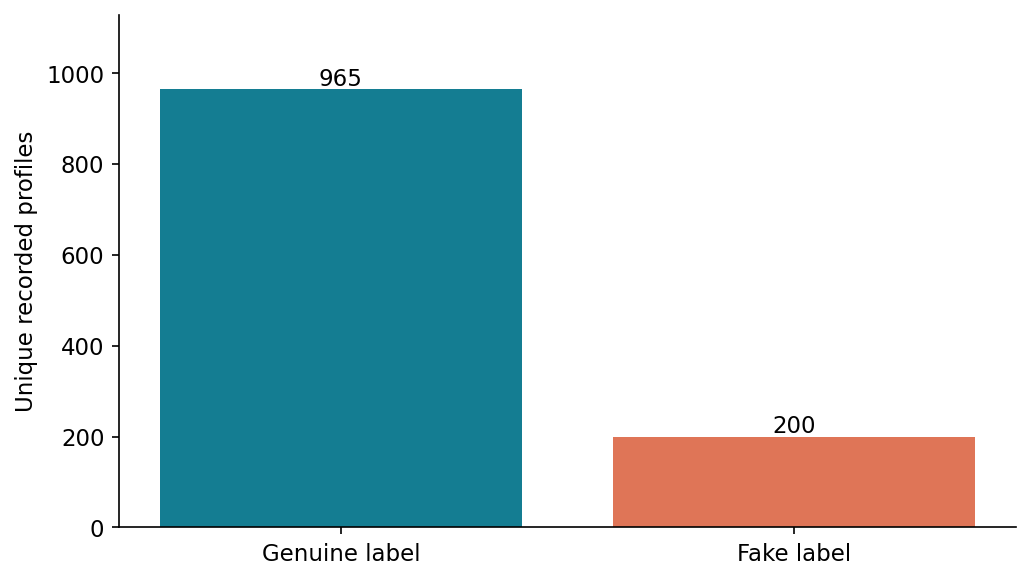

### Training CV and holdout fake-class F1

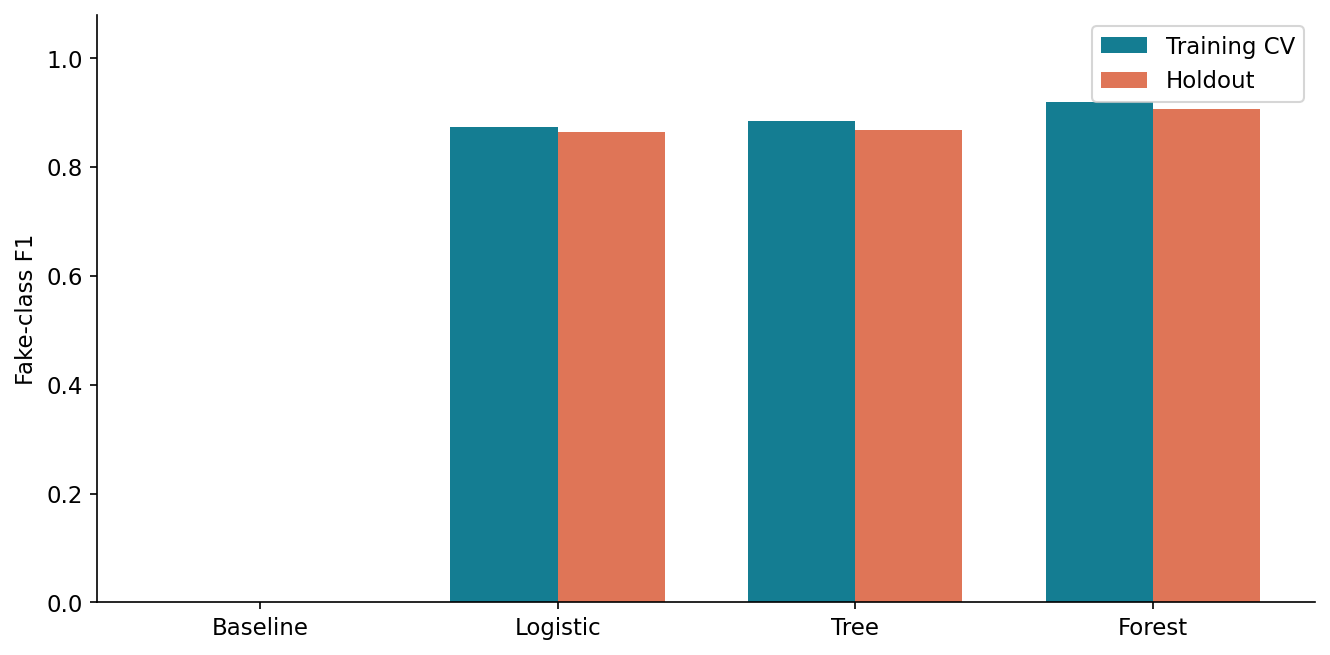

### Actual labels vs model predictions

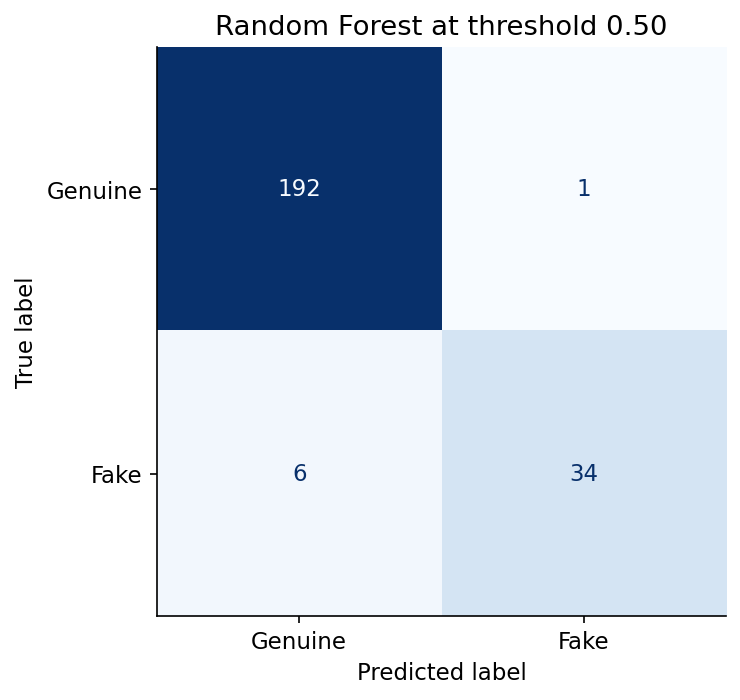

### Precision–recall tradeoff

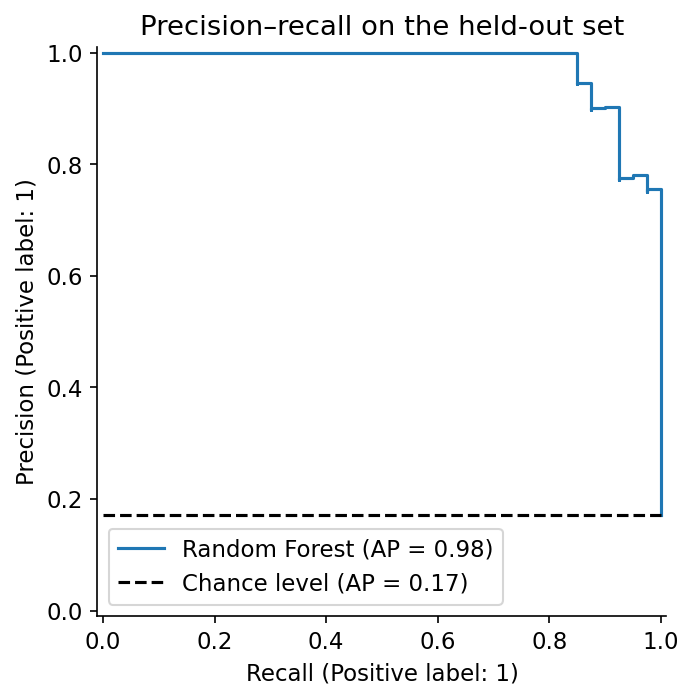

### Post-hoc permutation importance — predictive association, not causation

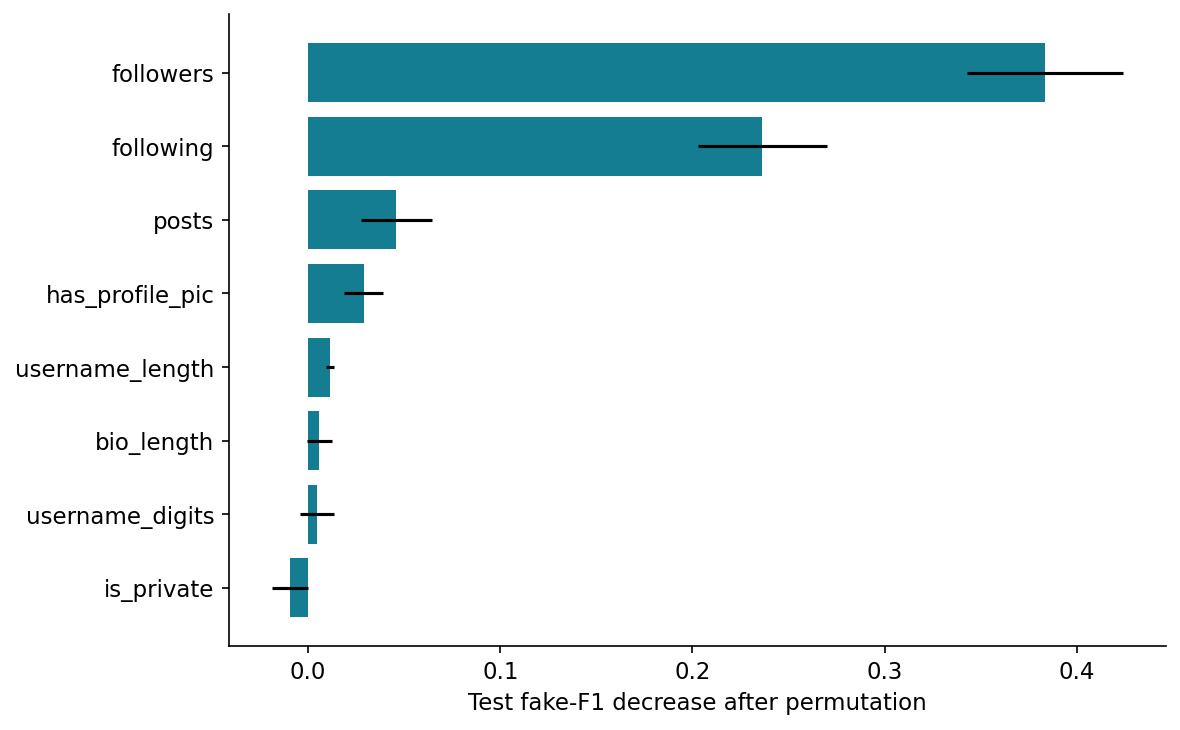

In [9]:
from IPython.display import display, Image, Markdown

for filename, caption in [
    ("class_balance.png", "Label distribution after deduplication"),
    ("comparison.png", "Training CV and holdout fake-class F1"),
    ("confusion_matrix.png", "Actual labels vs model predictions"),
    ("precision_recall.png", "Precision–recall tradeoff"),
    (
        "importance.png",
        "Post-hoc permutation importance — predictive association, not causation",
    ),
]:
    display(Markdown("### " + caption))
    display(Image(filename=str(ROOT / "results/figures" / filename), width=760))


## 7. Discussion
In the reference run, Random Forest detected 34 of 40 fake-labelled test profiles, missed six and raised one false alarm among 193 genuine-labelled profiles. The majority baseline detected no fake profiles despite achieving 82.83% accuracy. This is why fake-class F1 was used for model selection.

The fixed Logistic Regression feature comparison did not improve when the three engineered features were added. Permutation importance is calculated after model selection to describe the fitted model. The separate shallow tree is an illustration, not a representation of the forest's rules.

The data are small, historical and manually labelled. Account or campaign relationships are unknown, and the scores are uncalibrated. These results do not establish performance on current Instagram accounts.

Further work could use recent independently labelled data, group- or time-based evaluation, probability calibration and threshold selection on separate validation data.


## 8. Try a prediction
Enter the eight measurements and click **Analyze**, or use **Upload CSV** with the feature columns listed in Section 2. The fitted pipeline applies the transformations automatically.

The example buttons load existing test-set profiles for demonstration. Values outside training ranges are flagged. Predictions are saved in `results`. Scores are uncalibrated; a prediction does not verify account identity.


In [10]:
import ipywidgets as widgets
from predict import load_artifacts, predict_frame
from features import FEATURES

model, selection, ranges = load_artifacts()
examples = json.loads((ROOT / "data/demo_examples.json").read_text())
labels = {
    "followers": "Followers",
    "following": "Following",
    "bio_length": "Biography length",
    "posts": "Posts",
    "has_profile_pic": "Profile picture",
    "is_private": "Private account",
    "username_digits": "Username digits",
    "username_length": "Username length",
}
fields = {}
for key in FEATURES:
    options = dict(
        description=labels[key],
        style={"description_width": "180px"},
        layout=widgets.Layout(width="380px"),
    )
    fields[key] = (
        widgets.Dropdown(options=[("No", 0), ("Yes", 1)], **options)
        if key in ["has_profile_pic", "is_private"]
        else widgets.IntText(value=1 if key == "username_length" else 0, **options)
    )
output = widgets.Output()
example_note = widgets.HTML()
analyze = widgets.Button(description="Analyze", button_style="success")
genuine_btn = widgets.Button(description="Genuine example")
fake_btn = widgets.Button(description="Fake example")
csv_btn = widgets.Button(description="Upload CSV")


def fill_example(index):
    example = examples[index]
    for key, value in example["features"].items():
        fields[key].value = value
    example_note.value = f"Held-out example; actual label = {example['actual_label']} (0 genuine, 1 fake)."


def analyze_profile(_=None):
    with output:
        output.clear_output(wait=True)
        try:
            frame = pd.DataFrame([{key: field.value for key, field in fields.items()}])
            result = predict_frame(frame, model)
            display(result[["prediction", "fake_model_score"]])
            print(
                "Threshold: 0.50. Score is uncalibrated; this is not proof of identity."
            )
            outside = [
                key
                for key in FEATURES
                if not ranges[key]["min"] <= frame.iloc[0][key] <= ranges[key]["max"]
            ]
            if outside:
                print("Outside training ranges:", ", ".join(outside))
            result.to_csv(ROOT / "results/single_prediction.csv", index=False)
        except (ValueError, TypeError) as error:
            print("Please correct the input:", error)


def upload_csv(_):
    with output:
        output.clear_output(wait=True)
        try:
            from google.colab import files

            uploaded = files.upload()
            for name, content in uploaded.items():
                result = predict_frame(pd.read_csv(io.BytesIO(content)), model)
                dest = ROOT / "results" / (Path(name).stem + "_predictions.csv")
                result.to_csv(dest, index=False)
                display(result)
                print("Saved:", dest.name)
        except Exception as error:
            print("CSV upload/prediction failed:", error)


analyze.on_click(analyze_profile)
genuine_btn.on_click(lambda _: fill_example(0))
fake_btn.on_click(lambda _: fill_example(1))
csv_btn.on_click(upload_csv)
fill_example(0)
display(
    widgets.VBox(
        [
            widgets.HTML("<h2>ProfileLens — Account analysis</h2>"),
            *fields.values(),
            widgets.HBox([genuine_btn, fake_btn]),
            example_note,
            widgets.HBox([analyze, csv_btn]),
            output,
        ]
    )
)


## 9. Download results
Click **Download project ZIP** to save the code, data, trained model and results. Save this notebook separately using **File → Save a copy in Drive** or **File → Download → Download .ipynb**.

The accompanying `README.md` includes setup instructions, input requirements and dataset references.


In [11]:
import shutil

current_report = f"""# ProfileLens — Current Colab run
Selected model: {summary['winner']}
Accuracy: {summary['accuracy']:.4f}
Fake precision: {summary['fake_precision']:.4f}
Fake recall: {summary['fake_recall']:.4f}
Fake F1: {summary['fake_f1']:.4f}
Confusion matrix (actual rows genuine/fake; predicted columns genuine/fake): {summary['confusion_matrix']}
See results/environment.json for actual versions and raw hashes.
See the notebook for the methodology; current numbers are in results/.
"""
(ROOT / "CURRENT_RUN.md").write_text(current_report, encoding="utf-8")
(ROOT / "requirements-colab-tested.txt").write_text(
    "\n".join(f"{p}=={metadata.version(p)}" for p in requirements), encoding="utf-8"
)
export_button = widgets.Button(
    description="Download project ZIP",
    button_style="info",
    layout=widgets.Layout(width="230px"),
)
export_output = widgets.Output()


def export_project(_=None):
    with export_output:
        export_output.clear_output(wait=True)
        archive_path = shutil.make_archive(
            str(ROOT.parent / "ProfileLens_Colab_Results"), "zip", ROOT
        )
        try:
            from google.colab import files

            files.download(archive_path)
        except ImportError:
            print("Saved locally:", archive_path)


export_button.on_click(export_project)
display(export_button, export_output)
print("Ready. Click the button to download your current project files.")


Button(button_style='info', description='Download project ZIP', layout=Layout(width='230px'), style=ButtonStyl…

Output()

Ready. Click the button to download your current project files.


## References
1. Akyon, F. C., and Kalfaoglu, E. [InstaFake dataset](https://github.com/fcakyon/instafake-dataset), `data/fake-v1.0`, revision `cf669b27283aa3bc0fa6b8d185d4e611e9061ac1`.
2. Akyon, F. C., and Kalfaoglu, E. [Instagram Fake and Automated Account Detection](https://arxiv.org/abs/1910.03090).
3. Dataset license: [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/). Retain attribution and follow the noncommercial terms.
4. scikit-learn: [Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html) and [avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
